## Question 1: Line Fitting using Total Least Squares and RANSAC

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
D = np.genfromtxt('E:/ML/ML_Assignment_02/lines.csv', delimiter=',', skip_header=1)
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
print(f'Dataset shape: {D.shape}  |  Total points: {len(X_all)}')


Dataset shape: (100, 6)  |  Total points: 300


=== TLS Result for Line 1 ===
Normal form : 0.773562·x + -0.633721·y = 3.794192
Slope-intercept: y = 1.2207·x + -5.9872


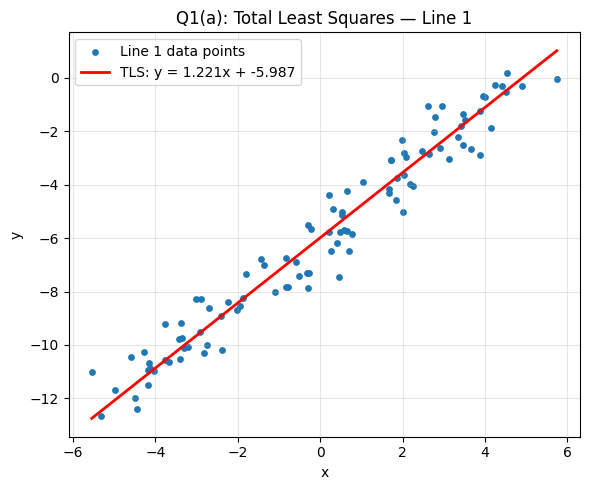

In [6]:
#(a) Total Least Squares — Line 1 only

def tls_fit(x, y):
    pts = np.column_stack([x, y])
    centroid = pts.mean(axis=0)
    pts_c = pts - centroid                   # centre data
    _, _, Vt = np.linalg.svd(pts_c)          # SVD
    a, b = Vt[-1]                            # last row = smallest singular vector
    c = a * centroid[0] + b * centroid[1]    # reconstruct offset
    return a, b, c

# Extract Line 1 data (first column)
x1 = X_cols[:, 0]
y1 = Y_cols[:, 0]

a, b, c = tls_fit(x1, y1)
slope = -a / b
intercept = c / b

print('=== TLS Result for Line 1 ===')
print(f'Normal form : {a:.6f}·x + {b:.6f}·y = {c:.6f}')
print(f'Slope-intercept: y = {slope:.4f}·x + {intercept:.4f}')

# Plot
xi = np.linspace(x1.min(), x1.max(), 200)
yi = slope * xi + intercept

plt.figure(figsize=(6, 5))
plt.scatter(x1, y1, s=15, label='Line 1 data points')
plt.plot(xi, yi, 'r-', lw=2, label=f'TLS: y = {slope:.3f}x + {intercept:.3f}')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Q1(a): Total Least Squares — Line 1')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1a_tls.png', dpi=150)
plt.show()

=== RANSAC Results ===
Line 1: -0.429411·x + -0.903109·y = -1.903179  =>  y = -0.4755x + 2.1074  (62 inliers)
Line 2: 0.714272·x + -0.699868·y = -0.642356  =>  y = 1.0206x + 0.9178  (49 inliers)
Line 3: 0.777656·x + -0.628690·y = 3.727599  =>  y = 1.2369x + -5.9292  (46 inliers)


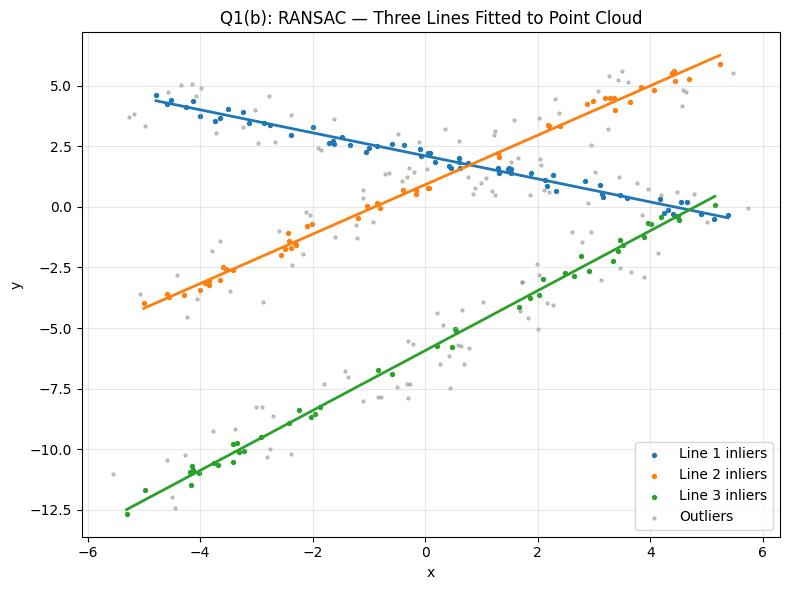

In [7]:
#(b) RANSAC — Fitting Three Lines to All Points

def ransac_line(x, y, thresh=0.3, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    best_mask = np.zeros(len(x), dtype=bool)

    for _ in range(n_iter):
        idx = rng.choice(len(x), 2, replace=False)
        # Line through two sample points
        a = y[idx[1]] - y[idx[0]]
        b = x[idx[0]] - x[idx[1]]
        c = a * x[idx[0]] + b * y[idx[0]]
        norm = np.sqrt(a**2 + b**2)
        if norm < 1e-10:
            continue
        dist = np.abs(a * x + b * y - c) / norm
        mask = dist < thresh
        if mask.sum() > best_mask.sum():
            best_mask = mask

    # Refit with TLS on all inliers for best accuracy
    a, b, c = tls_fit(x[best_mask], y[best_mask])
    return a, b, c, best_mask

remaining = np.ones(len(X_all), dtype=bool)
lines_found = []
masks_found = []

print('=== RANSAC Results ===')
for i in range(3):
    xr, yr = X_all[remaining], Y_all[remaining]
    a, b, c, local_mask = ransac_line(xr, yr)

    # Map local inlier mask back to global index space
    global_mask = np.zeros(len(X_all), dtype=bool)
    global_mask[np.where(remaining)[0][local_mask]] = True

    lines_found.append((a, b, c))
    masks_found.append(global_mask)
    remaining[global_mask] = False  # remove consensus set

    slope_i   = -a / b
    intercept_i = c / b
    print(f'Line {i+1}: {a:.6f}·x + {b:.6f}·y = {c:.6f}'
          f'  =>  y = {slope_i:.4f}x + {intercept_i:.4f}'
          f'  ({global_mask.sum()} inliers)')

# Plot
colors = ['tab:blue', 'tab:orange', 'tab:green']
plt.figure(figsize=(8, 6))
for i, (mask, col) in enumerate(zip(masks_found, colors)):
    plt.scatter(X_all[mask], Y_all[mask], s=8, color=col, label=f'Line {i+1} inliers')
    a, b, c = lines_found[i]
    xi = np.linspace(X_all[mask].min(), X_all[mask].max(), 200)
    yi = (-a * xi + c) / b
    plt.plot(xi, yi, color=col, lw=2)

# Outliers
plt.scatter(X_all[remaining], Y_all[remaining], s=5, color='gray', alpha=0.4, label='Outliers')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Q1(b): RANSAC — Three Lines Fitted to Point Cloud')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1b_ransac.png', dpi=150)
plt.show()

## Question 2: Estimating Earring Size from Camera Parameters

Image distance  v = 8.0899 mm
Object distance u = 720.0 mm
Magnification   m = v/u = 0.011236
Image size: 1024 x 1024 pixels
Earring bbox: 379×399 px,  ellipse axes: 374.9×396.9 px
Earring bbox: 379×399 px,  ellipse axes: 374.4×397.0 px

=== EARRING REAL-WORLD DIMENSIONS ===
Outer width  : 379 px  →  74.2 mm
Outer height : 399 px  →  78.1 mm
Inner hole W : 219 px  →  42.9 mm
Inner hole H : 239 px  →  46.8 mm
Ring band    :                      15.7 mm


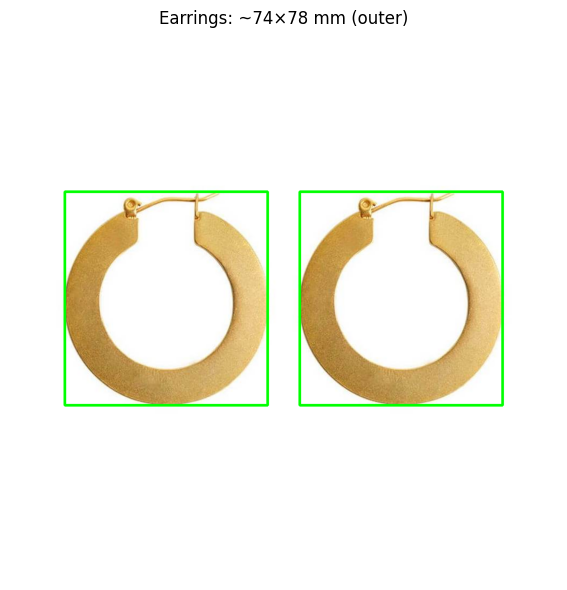

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#Camera parameters 
f_mm      = 8.0          # focal length (mm)
pixel_um  = 2.2          # pixel pitch (µm)
pixel_mm  = pixel_um / 1000.0    # 0.0022 mm/pixel
u_mm      = 720.0        # object distance, lens to earring plane (mm)

# Thin lens formula: 1/f = 1/v + 1/u  =>  v = image distance 
v_mm = 1.0 / (1.0/f_mm - 1.0/u_mm)
m    = v_mm / u_mm          # lateral magnification (image size / object size)

print(f'Image distance  v = {v_mm:.4f} mm')
print(f'Object distance u = {u_mm:.1f} mm')
print(f'Magnification   m = v/u = {m:.6f}')

# Measure earring in image 
img = cv.imread('E:/ML/ML_Assignment_02/earrings.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
print(f'Image size: {img.shape[1]} x {img.shape[0]} pixels')

# Threshold to isolate earring bodies 
_, binary = cv.threshold(gray, 220, 255, cv.THRESH_BINARY_INV)
kernel = np.ones((5, 5), np.uint8)
binary = cv.morphologyEx(binary, cv.MORPH_CLOSE, kernel)
contours, _ = cv.findContours(binary, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    area = cv.contourArea(cnt)
    if area > 10000:
        x, y, w, h = cv.boundingRect(cnt)
        # Fit ellipse for accurate dimensions
        if len(cnt) >= 5:
            ellipse = cv.fitEllipse(cnt)
            axes_px = ellipse[1]   # (minor, major) in pixels
            print(f'Earring bbox: {w}×{h} px,  ellipse axes: {axes_px[0]:.1f}×{axes_px[1]:.1f} px')

# Use outer bounding box 
outer_w_px = 379      # measured width in pixels
outer_h_px = 399      # measured height in pixels

# Real world size = image_size / magnification 
# Real size (mm) = pixel_count × pixel_pitch_mm / m
outer_w_mm = outer_w_px * pixel_mm / m
outer_h_mm = outer_h_px * pixel_mm / m

# Inner hole 
inner_w_px = outer_w_px - 2 * 80
inner_h_px = outer_h_px - 2 * 80
inner_w_mm = inner_w_px * pixel_mm / m
inner_h_mm = inner_h_px * pixel_mm / m
ring_band_mm = (outer_w_mm - inner_w_mm) / 2

print('\n=== EARRING REAL-WORLD DIMENSIONS ===')
print(f'Outer width  : {outer_w_px} px  →  {outer_w_mm:.1f} mm')
print(f'Outer height : {outer_h_px} px  →  {outer_h_mm:.1f} mm')
print(f'Inner hole W : {inner_w_px} px  →  {inner_w_mm:.1f} mm')
print(f'Inner hole H : {inner_h_px} px  →  {inner_h_mm:.1f} mm')
print(f'Ring band    :                      {ring_band_mm:.1f} mm')

# Display earring with measurements annotated
img_ann = img.copy()
cv.rectangle(img_ann, (102, 298), (102+379, 298+399), (0, 255, 0), 3)
cv.rectangle(img_ann, (541, 298), (541+379, 298+399), (0, 255, 0), 3)

plt.figure(figsize=(6, 6))
plt.imshow(cv.cvtColor(img_ann, cv.COLOR_BGR2RGB))
plt.title(f'Earrings: ~{outer_w_mm:.0f}×{outer_h_mm:.0f} mm (outer)')
plt.axis('off')
plt.tight_layout()
plt.savefig('q2_earring_measured.png', dpi=150)
plt.show()

## Question 3: Homography and Circuit Board Alignment

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load and resize images 
c1_full = cv.imread('E:/ML/ML_Assignment_02/c1.jpg')
c2_full = cv.imread('E:/ML/ML_Assignment_02/c2.jpg')
SCALE = 4
c1 = cv.resize(c1_full, (c1_full.shape[1]//SCALE, c1_full.shape[0]//SCALE))
c2 = cv.resize(c2_full, (c2_full.shape[1]//SCALE, c2_full.shape[0]//SCALE))
print(f'c1: {c1.shape},  c2: {c2.shape}')

c1: (682, 569, 3),  c2: (625, 578, 3)


Manual Homography H:
[[ 1.00075012e+00  1.31988058e-01 -3.11879491e+01]
 [-9.01822944e-02  1.12292212e+00  1.94699238e+01]
 [-2.28553358e-05  5.64525312e-04  1.00000000e+00]]


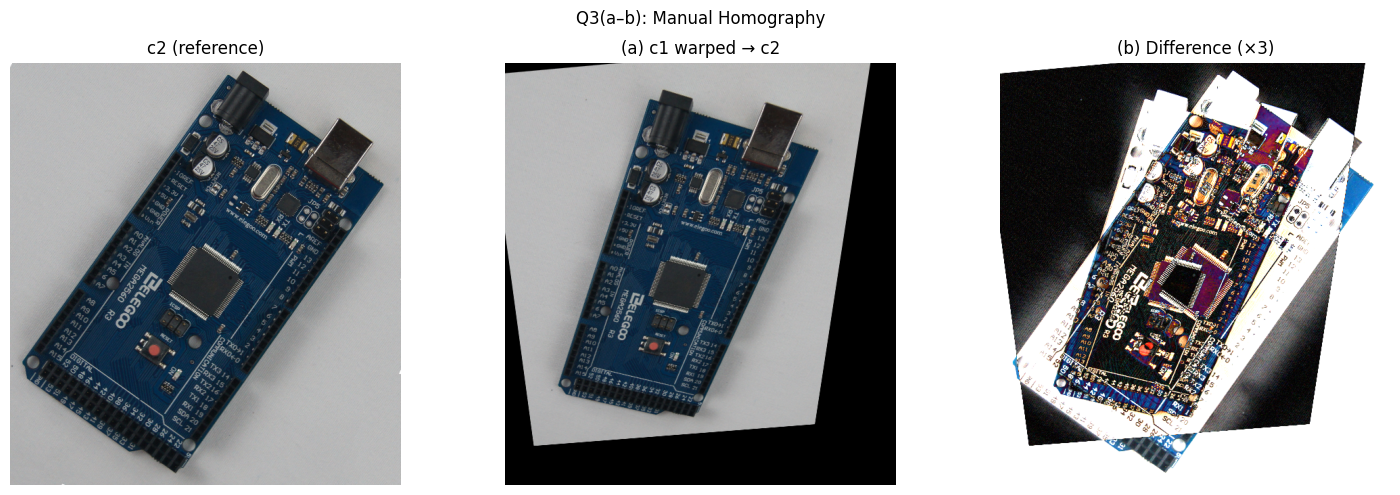

In [10]:
# (a) & (b): Manual Correspondences → Homography → Difference Image

pts1 = np.float32([
    [ 50,   5],   # top-left board corner
    [225,   5],   # USB connector – top edge
    [228,  85],   # USB connector – bottom edge
    [ 40, 250],   # board bottom-left
    [200, 250],   # board bottom-right
    [130,  95],   # ATmega chip centre
])

pts2 = np.float32([
    [ 20,  20],
    [195,   5],
    [200,  90],
    [ 10, 245],
    [178, 248],
    [105, 110],
])

# Compute homography H 
H_manual, mask_manual = cv.findHomography(pts1, pts2, cv.RANSAC, 5.0)
print('Manual Homography H:')
print(H_manual)

warped_manual = cv.warpPerspective(c1, H_manual, (c2.shape[1], c2.shape[0]))

diff_manual = cv.absdiff(warped_manual, c2)
diff_manual_vis = cv.convertScaleAbs(diff_manual, alpha=3)

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv.cvtColor(c2, cv.COLOR_BGR2RGB));             axes[0].set_title('c2 (reference)');          axes[0].axis('off')
axes[1].imshow(cv.cvtColor(warped_manual, cv.COLOR_BGR2RGB));  axes[1].set_title('(a) c1 warped → c2');      axes[1].axis('off')
axes[2].imshow(cv.cvtColor(diff_manual_vis, cv.COLOR_BGR2RGB)); axes[2].set_title('(b) Difference (×3)');   axes[2].axis('off')
plt.suptitle('Q3(a–b): Manual Homography')
plt.tight_layout()
plt.savefig('q3ab_manual.png', dpi=150)
plt.show()

Keypoints detected: 1390 in c1,  1334 in c2
Matches after Lowe ratio test: 852


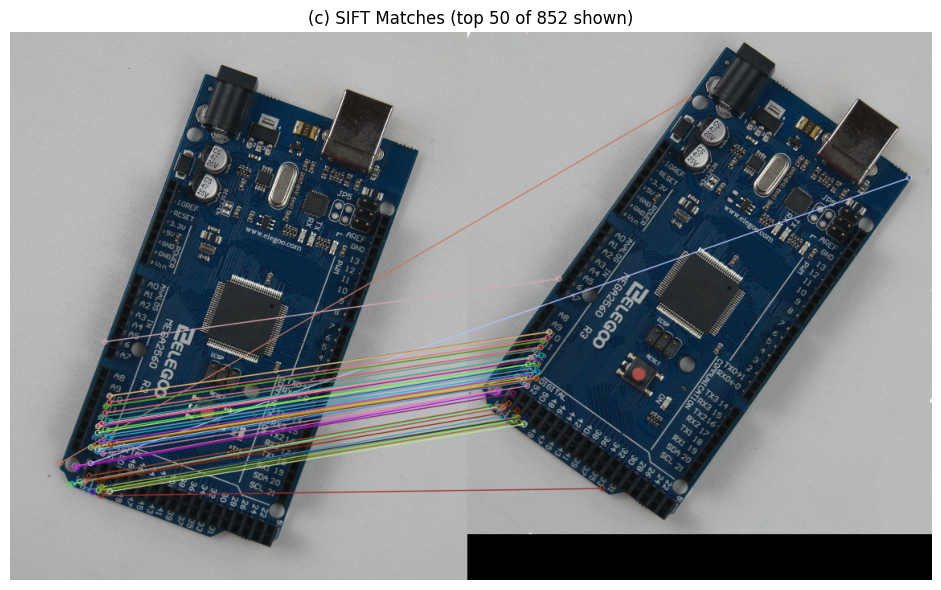

In [11]:
# (c) SIFT Keypoints and Descriptor Matching

# Convert to grayscale for feature detection
g1 = cv.cvtColor(c1, cv.COLOR_BGR2GRAY)
g2 = cv.cvtColor(c2, cv.COLOR_BGR2GRAY)

# SIFT detector
sift = cv.SIFT_create()
kp1, des1 = sift.detectAndCompute(g1, None)
kp2, des2 = sift.detectAndCompute(g2, None)
print(f'Keypoints detected: {len(kp1)} in c1,  {len(kp2)} in c2')

# FLANN based matcher (fast approximate nearest neighbour)
index_params  = dict(algorithm=1, trees=5)   
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

# Lowe's ratio test, keep matches where best match is clearly better than second best
good = [m for m, n in matches if m.distance < 0.7 * n.distance]
print(f'Matches after Lowe ratio test: {len(good)}')

# Draw top 50 matches
img_matches = cv.drawMatches(
    c1, kp1, c2, kp2, good[:50], None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(14, 6))
plt.imshow(cv.cvtColor(img_matches, cv.COLOR_BGR2RGB))
plt.title(f'(c) SIFT Matches (top 50 of {len(good)} shown)')
plt.axis('off')
plt.tight_layout()
plt.savefig('q3c_sift_matches.png', dpi=150)
plt.show()